# 第1章 环境准备

## 本章导读

开始写 kernel 之前，先确认当前 Python 进程能访问 GPU。本章依次检查：当前解释器是谁、
GPU 能否被看到、PyTorch 是否能计算，以及我们写的 HIP 是否能编译并与 Tensor 一起工作。

先准备环境，再从上到下运行。遇到错误时停在第一处失败，读完整信息后再往下走。
[对应正文](../../../docs/part0-intro/chapter1/index.md)包含终端层面的详细安装与排错说明。


## 1.1 本教程的实验基线

本书当前基线是 **Radeon RX 9070 XT、ROCm SDK 10.0、原生 Ubuntu 24.04**。
ROCm SDK 和 HIP 组件各自有版本号，所以 `torch.version.hip` 不必等于 SDK 版本。
后续结果以运行时读到的真实环境为准。

| 检查 | 通过后能说明什么 | 还不能说明什么 |
| --- | --- | --- |
| GPU 可见 | 当前进程能发现计算设备 | 任意算子或 profiling 工具均可用 |
| PyTorch 计算 | 框架可以提交并完成运算 | 手写 HIP 的编译工具链可用 |
| HIP smoke test | 当前 kernel 能编译、加载、计算 | 所有输入与优化都正确 |

其他 AMD GPU 或系统的工具可用性与性能，需要在对应机器上重新验证。
本套 notebook 不把某个 `gfx` 架构、wavefront 大小或带宽数字当作运行前提；
换卡时仍要先安装适合目标的设备依赖，不能把本机结果当作其他卡的实测。


In [ ]:
%run ../../common/bootstrap.py

import sys
import torch
import hello_gpu as gpu

cfg = gpu.settings()
context = gpu.environment(require_gpu=False)
{"Python 路径": sys.executable, "环境": context}


**观察**：`Python 路径` 应该指向本篇使用的环境。本次选择 `require_gpu=False`，
只读取当前系统与包信息，不探测 GPU；设备栏为空表示尚未探测，实际设备检查安排在 1.4。


## 1.2 平台边界：原生 Linux 优先，WSL2 需单独验证

驱动负责把硬件交给系统，ROCm 和 PyTorch 在此基础上提交计算。`uv` 管理环境里的依赖，
不会替你安装或修复系统内核驱动。原生 Linux 和 WSL2 的平台能力需要分别核对。

下面从当前 Python 查看系统与设备接口。它只读取信息，不修改驱动，也不会安装依赖。


In [ ]:
from pathlib import Path
import platform

{
    "系统": platform.system(),
    "内核": platform.release(),
    "KFD 设备接口存在": Path("/dev/kfd").exists(),
    "PyTorch HIP 组件": torch.version.hip,
}


**观察**：一个设备文件存在，只说明路径存在，不证明当前用户有访问权限。
同样，最小计算通过，也不证明硬件性能计数器能够采集；我们在 profiling 篇单独检验那些能力。


## 1.3 同步本篇 uv 环境

每篇使用独立的 Python 环境，避免其他章节的依赖变化影响当前实验。
`pyproject.toml` 描述依赖，`uv.lock` 固定解析出的版本，`.venv` 保存安装结果。

环境准备步骤集中在 [README](../../README.md)。这里检查当前解释器、公共教学包和实验配置，
确认后续单元使用的是预期环境。


In [ ]:
from pathlib import Path

{
    "Python 所在目录": str(Path(sys.executable).parent),
    "公共教学包": gpu.__version__,
    "默认实验配置": cfg,
}


## 1.4 验证 GPU 可见性

现在要求当前内核确实能访问 ROCm GPU。失败时先检查是否选错 Python 内核、驱动是否正常、
用户是否有设备访问权限；不要用 CPU 结果替代后面的 GPU 检查。


In [ ]:
context = gpu.environment()
{key: context[key] for key in ("gpu", "architecture", "memory_bytes", "torch", "hip")}


**观察**：把实际设备名称与预期机器核对。`architecture` 是当前识别出的目标，
不是 kernel 里需要手写的一串常量。如果这一步失败，终端中的 `rocminfo` 输出能帮助区分
底层设备问题和 Python 包问题，具体用法见本章正文。


## 1.5 验证 PyTorch ROCm

现在创建输入，让 PyTorch 真正做一次加法。固定随机种子使输入能够重复生成；
同时用 CPU 参考结果检查输出，而不是只看有没有报错。

PyTorch 的 ROCm 后端沿用 `device="cuda"` 和 `torch.cuda` 命名。
是否在使用 AMD 后端要看环境与 `torch.version.hip`，不能只看这个字符串。


In [ ]:
torch.manual_seed(cfg["seed"])
n = cfg["n"]
a_cpu = torch.randn(n, dtype=torch.float32)
b_cpu = torch.randn_like(a_cpu)
a, b = a_cpu.to("cuda"), b_cpu.to("cuda")
reference = a_cpu + b_cpu
torch_result = torch.add(a, b)
torch.testing.assert_close(torch_result.cpu(), reference, rtol=0, atol=0)
{"shape": tuple(torch_result.shape), "device": str(torch_result.device), "correct": True}


**观察**：`.to("cuda")` 将输入放到 GPU，`.cpu()` 让主机能够读取结果。
这次检查包含了数据传递，所以它是计算链路检查，尚不是 kernel 计时。


## 1.6 验证最小 HIP 程序

下图先把整个过程连起来。正文里的 C++ 程序显式分配、复制和释放存储；这里让 PyTorch Tensor
管理存储，`%%hip` 负责编译和调用包装。你仍能看到最重要的计算规则。


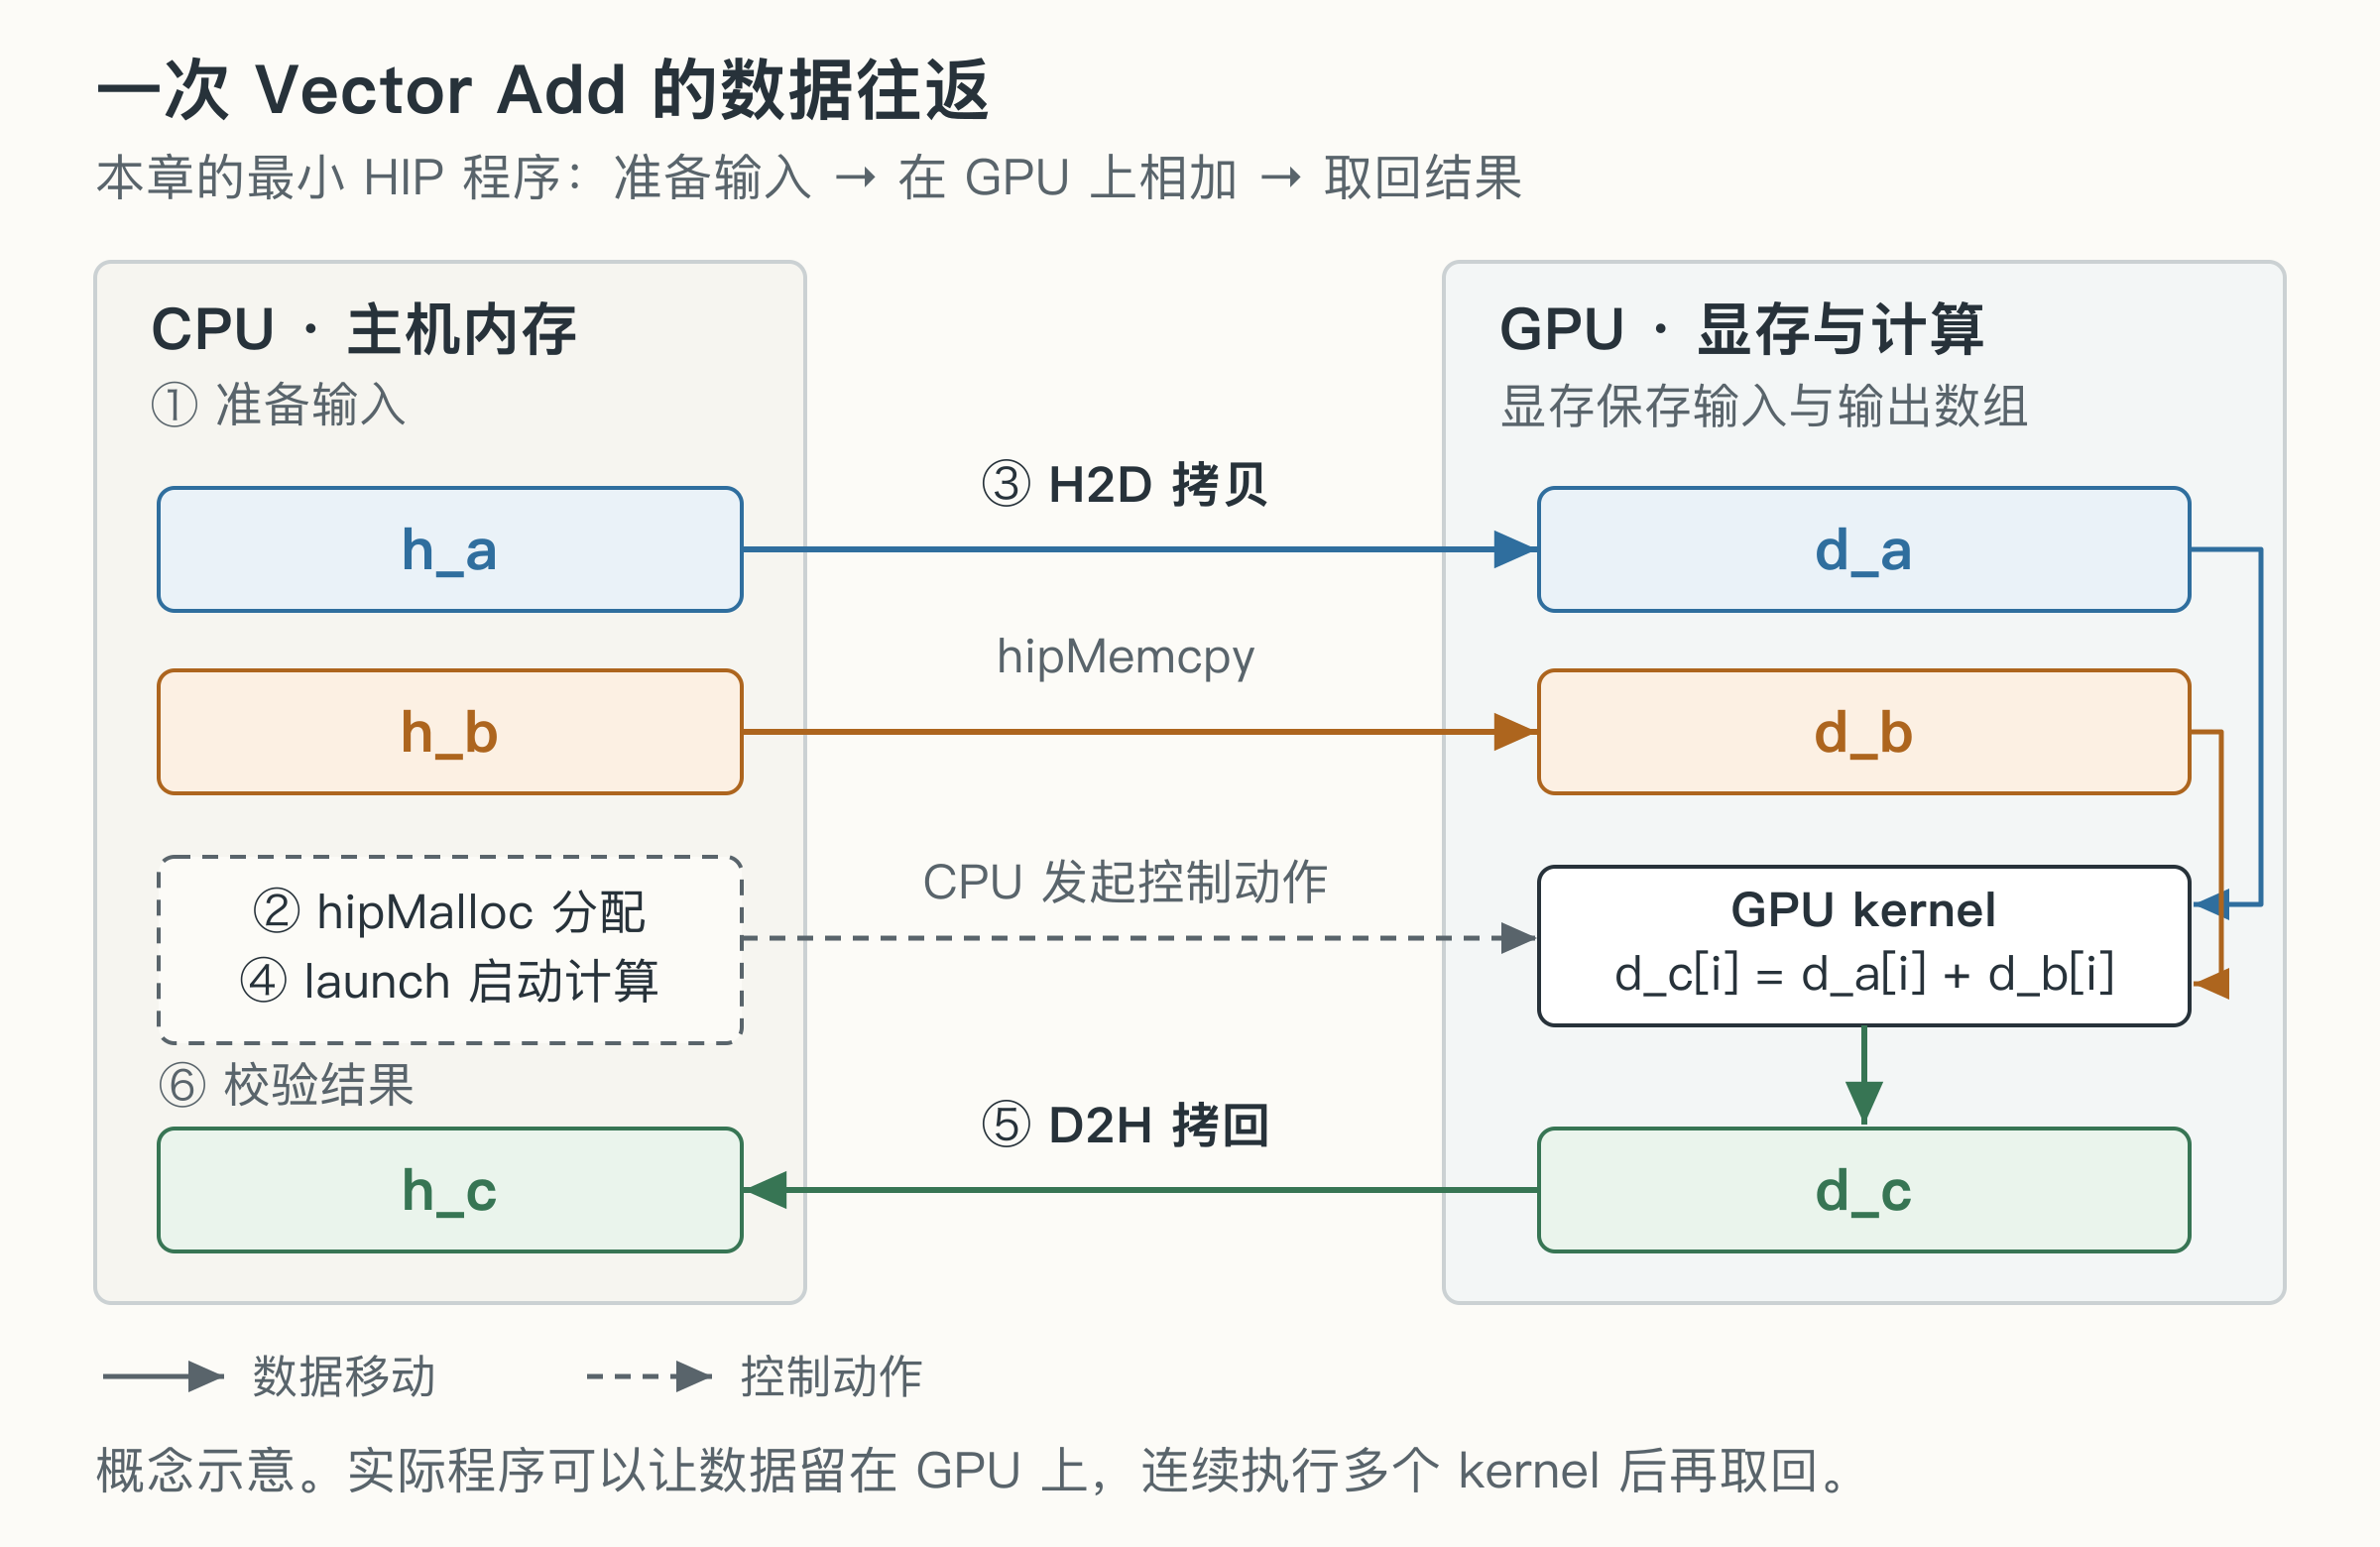

*输入从 CPU 到 GPU，kernel 写出结果，CPU 取回后检查。*


每个线程算一个下标，有效时读取两个数并写回。先照着运行，下一章再拆解这些编号。
`binary_f32` 约定两个连续 FP32 输入、一个同形状输出，以及元素个数 `n`。
它会根据 `block` 和数组长度安排足够的线程；输出由 Tensor 管理。


In [ ]:
%load_ext hello_gpu


In [ ]:
%%hip smoke_add --preset binary_f32

__global__ void kernel(const float* a, const float* b, float* c, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) c[i] = a[i] + b[i];
}


In [ ]:
out = torch.empty_like(a)
smoke_add(a, b, out=out, block=cfg["block"])
torch.testing.assert_close(out.cpu(), reference, rtol=0, atol=0)

tail_n = cfg["block"] + 3
x = torch.randn(tail_n, device="cuda")
y = torch.randn_like(x)
torch.testing.assert_close(smoke_add(x, y, block=cfg["block"]), x + y, rtol=0, atol=0)
{"checked_lengths": [n, tail_n], "correct": True}


**观察**：你只写了 kernel，调用时传入的仍然是普通 Tensor。
`out=` 允许复用已有输出；不提供它时，调用会新分配输出。非整除长度检查了最后一块的边界条件。

如果想确认它也能成为真正的 PyTorch 自定义算子，可以使用 `.op` 暴露的 `torch.ops` 入口。
本篇的实现只负责前向计算，输入不应设置 `requires_grad=True`。


In [ ]:
op = smoke_add.op
torch.testing.assert_close(op(x, y, block=cfg["block"]), x + y, rtol=0, atol=0)
{"operator": str(op), "build_id": smoke_add.build_id, "cache_hit": smoke_add.cache_hit}


第一次执行 HIP 单元需要编译；相同源码再次运行会复用缓存。修改函数体后再运行 HIP 单元，
才能让 Python 名字指向新的实现。编译失败时，报错会指向 notebook kernel 的行号和完整构建日志。


## 1.7 环境不通时先收集什么

把错误停在最早失败的一层：看不到设备，先检查系统；PyTorch 失败，检查内核与包；
PyTorch 成功而 HIP 编译失败，再检查工具链与源码。不要把不同层的问题混成“GPU 不行”。

| 需要保留的信息 | 从哪里得到 |
| --- | --- |
| Python 路径、系统、PyTorch/HIP 版本 | 1.1 与 1.2 的输出 |
| 实际设备与架构 | 1.4 的输出 |
| 最早失败的单元 | 单元输入与完整异常 |
| 编译位置与详细日志 | `%%hip` 的异常信息 |
| 最近一次改动 | 切换内核、同步依赖或修改源码的具体动作 |

### 练习

1. 重新运行 HIP 单元。缓存状态怎样变化？输入数据会跟着编译缓存一起保存吗？
2. 把输入长度改成 `2 * cfg["block"] + 1`，验证最后一个有效位置。
3. 有意把 `a[i] + b[i]` 改为减法，再运行旧的加法检查。失败反映的是环境问题还是数学规则变化？随后改回加法并重跑。

## 本章小结

我们分别验证了环境、PyTorch 运算与手写 HIP 的调用路径。接下来在
[第 2 章](../chapter2/chapter2.ipynb)中，把 kernel 里的线程编号一项项算清楚。
安装细节与换卡方法可回到[正文附录入口](../../../docs/part0-intro/chapter1/index.md)。
